## Qubit characterization notebook

This is an example notebook that run through the standard qubit characterization experiments.

In [ ]:
import matplotlib as mpl
mpl.rcParams['axes.formatter.use_mathtext'] = False

%matplotlib widget
%load_ext autoreload
%autoreload 2
from IPython.display import display, HTML
css = """
<style>
    /*overwrite hard coded write background by vscode for ipywidges */
    .cell-output-ipywidget-background {
    background-color: transparent !important;
    }

    /*set widget foreground text and color of interactive widget to vs dark theme color */
    :root {
        --jp-widgets-color: var(--vscode-editor-foreground);
        --jp-widgets-font-size: var(--vscode-editor-font-size);
    }
</style>
"""
display(HTML(css))

import matplotlib.pyplot as plt
import numpy as np
# plt.style.use("dark_background")


try: # if using the new qcodes based instrumet server
    from instrumentserver.client import ClientStation  
    instrument_station = ClientStation(host='localhost', timeout=600, init_instruments = None)
except ImportError as e: # make a fall back dummy object
    instrument_station =  type('Dummy', (), {})()
    instrument_station.save_parameters = lambda *args:  None


# a simple python file that stores global settings
from system_info import DATA_DIR, BOARD_IP, YAML_PATH



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Example of controlling instruments:

In [ ]:
# print(instrument_station.instruments)
# instrument_station["sc_spa_lincA"].power()

# Ro Spec

In [ ]:
from acadia_qmsmt.runtimes.resonator_spectroscopy import  ResonatorSpectroscopyRuntime

freqs = np.linspace(-1e6, 1e6, 101) + 9.0008e9
iterations = 500
run_delay = 2000
rt = ResonatorSpectroscopyRuntime(stimulus="ro_stimulus", capture="ro_capture", frequencies=freqs, plot=True, iterations=iterations, run_delay=run_delay, yaml_path=YAML_PATH)
rt.deploy(BOARD_IP, local_directory=DATA_DIR + "RoSpec/%y%m%d/%H%M%S")
rt.display()
_ = instrument_station.save_parameters(rt.local_directory + "/inst_params.json")

Output()

[2025-05-26 14:32:03,422] WARNING at event_loop (runtime.py, 644): Unable to connect to target DataManager
[2025-05-26 14:32:47,247] ERROR at event_loop (runtime.py, 656): Exception synchronizing: Traceback (most recent call last):
  File "/home/acadia/pyacadia/acadia/runtime.py", line 653, in event_loop
    self.data.sync(timeout_ms=5000)
TimeoutError: Timeout occurred polling for read



### RO Spec prep Qubit (rough $\chi$ msmt)

In [15]:
from acadia_qmsmt.runtimes.resonator_spectroscopy_prepQubit import  ResonatorSpectroscopyPrepQubitRuntime

freqs = np.linspace(-4e6, 4e6, 101) + 9.0004e9
qubit_prep_pulse_mem = "R_x_90"
iterations = 500
run_delay = 2000
rt = ResonatorSpectroscopyPrepQubitRuntime(stimulus="ro_stimulus", capture="ro_capture", qubit_stimulus="qb_stimulus",  
                                        frequencies=freqs, qubit_prep_pulse_mem=qubit_prep_pulse_mem, 
                                        plot=True, iterations=iterations, run_delay=run_delay, yaml_path=YAML_PATH)
rt.deploy(BOARD_IP, local_directory=DATA_DIR + "RoSpec/prep_qubit/%y%m%d/%H%M%S")
rt.display()
_ = instrument_station.save_parameters(rt.local_directory + "/inst_params.json")

Output()

[2025-05-26 14:34:00,070] WARNING at event_loop (runtime.py, 644): Unable to connect to target DataManager


/home/acadia_qmsmt/acadia_qmsmt/runtimes/resonator_spectroscopy_prepQubit.py:147: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


# Ro window calibration (simple)

In [ ]:
from acadia_qmsmt.runtimes.readout_window_calibration import  ReadoutWindowCalibrationRuntime

plot = True
iterations = 20000
qubit_pulse_waveform_name = "R_x_180"
qubit_pulse_name = "rotation"
rt = ReadoutWindowCalibrationRuntime(qubit_stimulus="qb_stimulus", readout_stimulus="ro_stimulus", readout_capture="ro_capture",
                           qubit_pulse_waveform_name=qubit_pulse_waveform_name, qubit_pulse_name=qubit_pulse_name,
                           readout_stimulus_memory="readout", readout_stimulus_waveform="readout",
                           readout_capture_memory="readout_trace", readout_capture_window="boxcar",
                           iterations=iterations, plot=plot, generate_kernel=True, yaml_path=YAML_PATH)
rt.deploy(BOARD_IP, local_directory=DATA_DIR + "RoTrace/%y%m%d/%H%M%S")
rt.display()
_ = instrument_station.save_parameters(rt.local_directory + "/inst_params.json")

# Ro Calibration (comprehensive)

In [ ]:
from acadia_qmsmt.runtimes.readout_calibration import  ReadoutCalibrationRuntime

readout_frequencies = [9.01727e9] #np.linspace(-0.5e6, 0.5e6, 3) + 9.017e9
readout_amplitudes = [0.4]
saturation_pulse_fixed_length = 2e-3
saturation_pulse_amplitude = 0.02
iterations = 5000
run_delay = 200
rt = ReadoutCalibrationRuntime(qubit_stimulus="qb_stimulus", readout_stimulus="ro_stimulus", readout_capture="ro_capture", 
                               readout_frequencies=readout_frequencies, readout_amplitudes=readout_amplitudes, 
                               saturation_pulse_fixed_length=saturation_pulse_fixed_length, saturation_pulse_amplitude=saturation_pulse_amplitude,
                               plot=True, iterations=iterations, yaml_path=YAML_PATH)
rt.deploy(BOARD_IP)
rt.display()

In [ ]:
raw_traces = rt.data["traces"].records()
raw_data = np.sum(raw_traces, axis=1)
plt.figure()
_=plt.hist2d(raw_data[:,0], raw_data[:,1], bins=51)

# Readout Histogram & Metrics (Fidelity, etc.)

In [6]:
from acadia_qmsmt.runtimes.readout_fidelity_metrics import  ReadoutFidelityRuntime

iterations = 20000
run_delay = 200e3
readout_window_name = "matched"

num_prep_rounds = 2

qubit_pulse_name = "rotation"
qubit_pulse_waveform_name = "R_x_180"
rt = ReadoutFidelityRuntime(qubit_stimulus="qb_stimulus", readout_stimulus="ro_stimulus", readout_capture="ro_capture", 
                            qubit_pulse_name=qubit_pulse_name, qubit_pulse_waveform_name=qubit_pulse_waveform_name,
                            readout_window_name=readout_window_name,
                            plot=True, iterations=iterations, run_delay=run_delay, yaml_path=YAML_PATH,num_prep_rounds=num_prep_rounds)
rt.deploy(BOARD_IP, local_directory=DATA_DIR + "Readout_Hist_and_Metrics/%y%m%d/%H%M%S")
rt.display()
_ = instrument_station.save_parameters(rt.local_directory + "/inst_params.json")

[2025-05-26 14:21:06,654] WARNING at event_loop (runtime.py, 644): Unable to connect to target DataManager


Output()

# Qubit Spec

In [ ]:
from acadia_qmsmt.runtimes.qubit_spectroscopy import  QubitSpectroscopyRuntime

qubit_center_freq = 8.094e9

qubit_frequencies = np.linspace(-5e6, 5e6, 81) + qubit_center_freq
saturation_pulse_fixed_length = 30e-6
saturation_pulse_amplitude = 0.01

# qubit_frequencies = np.linspace(-5e6, 5e6, 81) + qubit_center_freq
# saturation_pulse_fixed_length = 5e-6
# saturation_pulse_amplitude = 0.09

iterations = 200
run_delay = 2000
readout_window_name = "matched"
# readout_window_name = "boxcar"
rt = QubitSpectroscopyRuntime(qubit_stimulus="qb_stimulus", readout_stimulus="ro_stimulus", readout_capture="ro_capture", 
                              qubit_frequencies=qubit_frequencies, 
                              saturation_pulse_fixed_length=saturation_pulse_fixed_length, saturation_pulse_amplitude=saturation_pulse_amplitude,
                              readout_window_name = readout_window_name,
                              plot=True, iterations=iterations, run_delay=run_delay, yaml_path=YAML_PATH)
rt.deploy(BOARD_IP,local_directory=DATA_DIR + "Qubit_spec/%y%m%d/%H%M%S")
rt.display()


# Qubit Rabi

In [21]:
from acadia_qmsmt.runtimes.qubit_pulse_amplitude_calibration import  QubitPulseAmplitudeCalibrationRuntime

cal_selective = False
iterations = 1000
run_delay = 2e5
readout_window_name = "matched"
# readout_window_name = "boxcar"

if cal_selective:
    qubit_pulse_name = "rotation_selective"
    qubit_pulse_waveform_name = "R_x_180_selective"
    qubit_amplitudes = np.linspace(-0.15, 0.15, 51)
else:
    qubit_pulse_name = "rotation"
    qubit_pulse_waveform_name = "R_x_180"
    qubit_amplitudes = np.linspace(-0.9, 0.9, 51)

rt = QubitPulseAmplitudeCalibrationRuntime(qubit_stimulus="qb_stimulus", readout_stimulus="ro_stimulus", readout_capture="ro_capture", 
                                  qubit_amplitudes=qubit_amplitudes,readout_window_name=readout_window_name,
                                  qubit_pulse_name=qubit_pulse_name, qubit_pulse_waveform_name=qubit_pulse_waveform_name,
                                  plot=True, iterations=iterations, run_delay=run_delay, yaml_path=YAML_PATH)
rt.deploy(BOARD_IP, local_directory=DATA_DIR + "Qubit_Rabi/%y%m%d/%H%M%S")
rt.display()

print(rt.local_directory)


Output()

/home/rsl/Data/LINC_Cooldown_20250506/ChipA//Qubit_Rabi/250526/144311


[2025-05-26 14:43:11,793] WARNING at event_loop (runtime.py, 644): Unable to connect to target DataManager


### Qubit Rabi with prepare (shows an example usage of realtime feedback)

In [ ]:
from acadia_qmsmt.runtimes.qubit_rabi_with_preapare import  QubitRabiWithPrepareRuntime


# qubit_amplitudes = [0.0, 0.0]
iterations = 5000
run_delay = 200e3
cal_selective = False
readout_window_name = "matched"

qubit_pulse_name = "rotation"
qubit_pulse_waveform_name = "R_x_180"
qubit_amplitudes = np.linspace(-0.9, 0.9, 51)

if cal_selective:
    qubit_pulse_name = "rotation_selective"
    qubit_pulse_waveform_name = "R_x_180_selective"
    qubit_amplitudes = np.linspace(-0.2, 0.2, 51)

prepare_quadrant = 1
prepare_pulse_name = "rotation_2" # can't be the same as the one used for rabi
prepare_pulse_waveform_name = "R_x_180"

rtp = QubitRabiWithPrepareRuntime(qubit_stimulus="qb_stimulus", readout_stimulus="ro_stimulus", readout_capture="ro_capture", 
                                  qubit_amplitudes=qubit_amplitudes,readout_window_name=readout_window_name,
                                  qubit_pulse_name=qubit_pulse_name, qubit_pulse_waveform_name=qubit_pulse_waveform_name,
                                  plot=True, iterations=iterations, run_delay=run_delay,
                                  prepare_quadrant=prepare_quadrant,
                                  prepare_pulse_name=prepare_pulse_name, prepare_pulse_waveform_name=prepare_pulse_waveform_name,
                                  yaml_path=YAML_PATH
                                  )
rtp.deploy(BOARD_IP, local_directory=DATA_DIR + "QubitRabiWithPrepare/%y%m%d/%H%M%S")
rtp.display()

print(rtp.local_directory)

# Qubit ef spec

Label(value='', style=LabelStyle(description_width='initial'))

Iterations:   0%|          | 0/3000 [00:00<?, ?it/s]

Output()

[2025-05-26 14:50:21,555] WARNING at event_loop (runtime.py, 644): Unable to connect to target DataManager


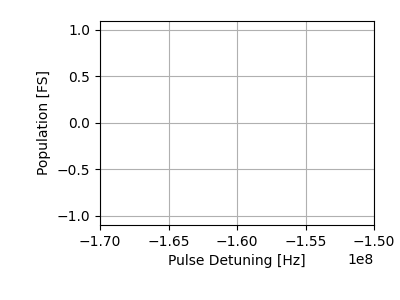

In [23]:
from acadia_qmsmt.runtimes.qubit_anharmonicity import  QubitAnharmonicityRuntime

frequencies = np.linspace(-170e6, -150e6, 101) 

qubit_pulse_name = "rotation"
qubit_pulse_waveform_name = "R_x_180"
ef_pulse_length = 3e-6
ef_pulse_scale = 0.5
iterations = 3000
run_delay = 200e3 #ns
readout_window_name = "matched"

rt = QubitAnharmonicityRuntime(qubit_stimulus="qb_stimulus", readout_stimulus="ro_stimulus", readout_capture="ro_capture", 
                               qubit_pulse_name=qubit_pulse_name, qubit_pulse_waveform_name=qubit_pulse_waveform_name,
                               ef_pulse_length=ef_pulse_length, ef_pulse_scale=ef_pulse_scale, 
                               frequencies=frequencies,readout_window_name=readout_window_name,
                               plot=True, iterations=iterations, run_delay=run_delay, yaml_path=YAML_PATH)
rt.deploy(BOARD_IP, local_directory=DATA_DIR + "Qubit_efSpec/%y%m%d_%H%M%S")
rt.display()

# Qubit T1

In [ ]:
from acadia_qmsmt.runtimes.qubit_relaxation import  QubitRelaxationRuntime

delay_times = np.linspace(0, 300e-6, 41) + 800e-9
iterations = 5000
run_delay = 500e3
readout_window_name = "matched"
# qubit_pulse_name = "rotation_selective"
# qubit_pulse_waveform_name = "R_x_180_selective"
qubit_pulse_name = "rotation"
qubit_pulse_waveform_name = "R_x_180"
rt = QubitRelaxationRuntime(qubit_stimulus="qb_stimulus", readout_stimulus="ro_stimulus", readout_capture="ro_capture", 
                            delay_times=delay_times,
                            qubit_pulse_name=qubit_pulse_name, qubit_pulse_waveform_name=qubit_pulse_waveform_name,
                            readout_window_name=readout_window_name,
                            plot=True, iterations=iterations, run_delay=run_delay, yaml_path=YAML_PATH)
rt.deploy(BOARD_IP, local_directory=DATA_DIR + "Qubit_T1/%y%m%d/%H%M%S")
rt.display()
_ = instrument_station.save_parameters(rt.local_directory + "/inst_params.json")

# Qubit T2

In [31]:
from acadia_qmsmt.runtimes.qubit_coherence import  QubitCoherenceRuntime

delay_times = np.linspace(0, 30e-6, 101) + 600e-9
pulse_type = ""
qubit_first_pulse_waveform_name = "R_x_90" + pulse_type
qubit_first_pulse_name = "rotation" + pulse_type
qubit_second_pulse_waveform_name = "R_x_90" + pulse_type
qubit_second_pulse_name = "rotation" + pulse_type + "_2"

virtual_detuning = -0.3e6
iterations = 5000
run_delay = 500e3
readout_window_name = "matched"
rt = QubitCoherenceRuntime(qubit_stimulus="qb_stimulus", readout_stimulus="ro_stimulus", readout_capture="ro_capture", 
                           delay_times=delay_times, virtual_detuning=virtual_detuning,
                           qubit_first_pulse_waveform_name=qubit_first_pulse_waveform_name, qubit_first_pulse_name=qubit_first_pulse_name,
                           qubit_second_pulse_waveform_name=qubit_second_pulse_waveform_name, qubit_second_pulse_name=qubit_second_pulse_name,
                           readout_window_name=readout_window_name,
                           plot=True, iterations=iterations, run_delay=run_delay, yaml_path=YAML_PATH)
rt.deploy(BOARD_IP, local_directory=DATA_DIR + "Qubit_T2/%y%m%d_%H%M%S")
rt.display()
_ = instrument_station.save_parameters(rt.local_directory + "/inst_params.json")

Output()

[2025-05-26 14:58:40,596] WARNING at event_loop (runtime.py, 644): Unable to connect to target DataManager
